In [11]:
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits
import astropy.coordinates
import fitsio
import sdss_access

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

sdss_path = sdss_access.path.Path(release='dr19', verbose=True)

#### load the SDSS allspec database (do not edit this cell, takes a few minutes)

In [2]:
access = sdss_access.Access(release='dr19', verbose=True)
allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('',full=allspec_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()
print(allspec_file)

# this step is slow give it time the allspec file is enormous
allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

/home/idies/workspace/sdss_sas/dr19/spectro/allspec/1.0.1/allspec-dr19-1.0.1.fits.gz


#### load the SDSS BOSS spAll database (do not edit this cell, takes a minute)

In [3]:
# this step loads data from the spall file and so can take several minutes to run
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('',full=spall_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()
print(spall_file)

spall_columns = ['SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS', 'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE','HEALPIX_PATH','OBJTYPE']
spall = fitsio.read(spall_file, columns=spall_columns)

/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz


### select a flux-limited sample from spAll

1. define a sample by g-band magnitude and signal-to-noise

In [1]:
# add code to select a flux-limited sample of all quasars with:
# g-band magnitude between 18.07 and 18
# median signal to noise > 30
# OBJTYPE=='QSO'
# (the really narrow range in magnitude is to limit the number of objects since unfortunately I haven't found a fast way to find files from spAll)
indx = np.where(XX)

# grab unique sdssid values for these objects
sdssid_sample = spall['SDSS_ID'][indx]
sdssid_sample_unique, indx_unique = np.unique(sdssid_sample,return_index=True)

NameError: name 'np' is not defined

In [9]:
len(indx[0])

210

2. select one spectrum per object (code copied from allspec.ipynb and our past notebooks)

In [12]:
file_list = []; k = 0
for sdssid in sdssid_sample_unique:
    imatch = np.where(allspec['sdss_id'] == sdssid)[0]
    local_path = allspec['sas_url'][imatch[0]].decode().replace(url_root, local_root)
    file_list.append(local_path)
    k=k+1
    print(k)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98


3. measure and record the continuum flux for each object

In [13]:
# load all of the data files with good signal to noise ('COADD' data extension)
boss_visits = []
mjds = []
z = []
k=0
for file in file_list:
    spec_hdulist = astropy.io.fits.open(file)
    print(k,spec_hdulist[2].data['SN_MEDIAN_ALL'],spec_hdulist[2].data['Z'])
    k=k+1
    if (spec_hdulist[2].data['SN_MEDIAN_ALL'] > 10.) & (spec_hdulist[2].data['Z'] > 0.01):
        visit = np.array(spec_hdulist['COADD'].data)
        boss_visits.append(visit)
        mjds.append(spec_hdulist[0].header['MJD'])
        z.append(spec_hdulist[2].data['Z'][0])

0 [18.519377] [0.00021104]
1 [12.425123] [0.15339278]
2 [28.313068] [-0.00011576]
3 [15.700043] [8.816031e-05]
4 [28.812849] [0.00013945]
5 [45.756554] [-4.3992008e-05]
6 [30.757511] [2.6484332]
7 [27.33078] [0.32563952]
8 [19.299877] [0.545437]
9 [43.62166] [-0.00013124]
10 [25.082] [0.5218501]
11 [40.83628] [4.84608e-05]
12 [49.103783] [0.00016543]
13 [45.05657] [-0.00011404]
14 [11.487813] [0.00012524]
15 [41.23377] [0.00021021]
16 [17.609322] [0.78992474]
17 [30.349752] [0.000123]
18 [20.565681] [0.4813989]
19 [21.269838] [1.4625336]
20 [23.625614] [2.3000703]
21 [30.709135] [-0.00034334]
22 [19.326433] [0.74491525]
23 [19.918652] [0.7645055]
24 [16.322403] [0.8240954]
25 [33.82005] [2.9667019e-05]
26 [40.854523] [8.249058e-05]
27 [19.440966] [0.5790654]
28 [0.] [0.]
29 [20.571693] [0.7039874]
30 [35.171318] [1.3379345]
31 [8.545616] [0.10587355]
32 [18.819757] [1.0799516]
33 [15.9828415] [1.7610987]
34 [14.716224] [1.8105661]
35 [28.7528] [3.0795271]
36 [17.07369] [0.59475034]
37 

In [14]:
# let's make a continuum light curve at 4500 Angstrom with error bars from the scatter in the data
flux_4500 = []
flux_4500_err = []

for visit in boss_visits:
    try:
        lam = 10**visit['LOGLAM']
        flux = visit['FLUX']
    except:
        lam = 10**visit['loglam']
        flux = visit['flux']
    # write code to calculate the median flux +/- 50 indices around an observed wavelength of 4500 Angstrom
    # and the uncertainty in the value as the standard deviation (np.std) of those values
    lam_4500=XX
    flux_4500.append(XX)
    flux_4500_err.append(XX)

[WARNING]: Mean of empty slice. (RuntimeWarning)
[WARNING]: invalid value encountered in divide (RuntimeWarning)


4. convert the flux to luminosity

Use the equation $L = 4\pi D_L^2 \lambda_{\rm obs} F_{\lambda_{\rm obs}}$ to convert our fluxes to luminosities

In [23]:
from astropy.cosmology import WMAP9 as cosmo
dl=np.array(cosmo.luminosity_distance(np.array(z)),dtype=float)

# calculate the luminosity values here
L_4500 = XX

5. plot the luminosity vs. redshift and the flux vs. redshift

be sure to use matplotlib symbols (e.g., marker='o') and turn off lines (linestyle='')

you could also try out the plt.scatter command if you like

Text(0, 0.5, 'luminosity $\\lambda L_\\lambda$ (erg s$^{-1}$)')

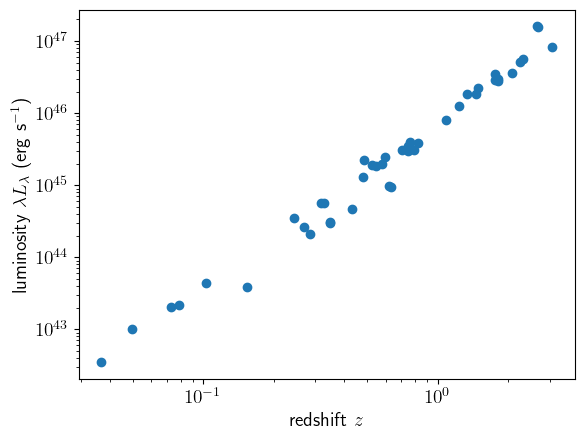

In [24]:
XX
plt.xlabel('redshift $z$'); plt.ylabel('luminosity $\lambda L_\lambda$ (erg s$^{-1}$)')

repeat here but for plotting your flux flux_4500 vs. redshift

Text(0, 0.5, 'flux $F_\\lambda$ (10$^{-17}$ erg cm$^{-2}$ s$^{-1}$ $\\AA^{-1}$')

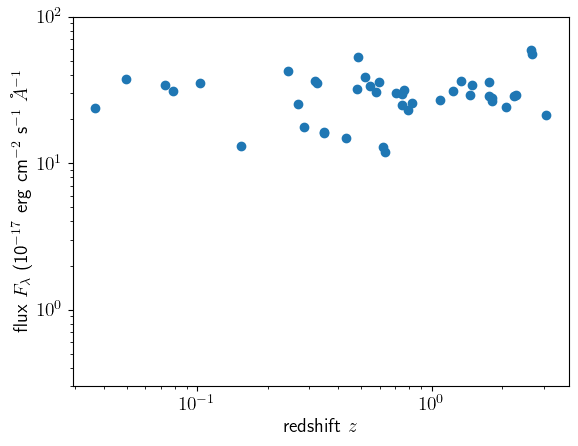

In [25]:
XX
# plotting limit to show a rough range of what is possible to detect in SDSS-V observations
plt.ylim(3e-1,1e2)
plt.xlabel('redshift $z$'); plt.ylabel('flux $F_\lambda$ (10$^{-17}$ erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$')

6. what do you make of the result? is there a clear trend? discuss briefly.

### select a "volume"-limited sample from spAll selecting by location on the sky

this is allspec tutorial code for finding separation of objects from a target position, no need to modify

In [26]:
center_ra = [153.]
center_dec = [10.]
center_coords = astropy.coordinates.SkyCoord(center_ra, center_dec, unit='deg', frame='icrs')

unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords)
sep = sep.value   # get separation from each object and target location in units of degrees

7. select a sample as objects closer than either 0.5 deg (faster to run) or 1.5 deg (neat plot but takes ~10 minutes)

In [27]:
# enter your value here
sep_max = XX
indx = np.where(sep < sep_max)
print(len(indx[0]))

154


8. load one file per object

In [28]:
spectrum_files = []
for p in allspec["sas_url"][indx]:
    local_path = p.decode().replace(url_root, local_root)
    spectrum_files.append(local_path)

In [29]:
# load all of the data files with good signal to noise ('COADD' data extension)
boss_visits = []
mjds = []
z = []
for file in spectrum_files:
    spec_hdulist = astropy.io.fits.open(file)
    if (spec_hdulist[2].data['SN_MEDIAN_ALL'] > 1.) & (spec_hdulist[2].data['Z'] > 0.1):
        visit = np.array(spec_hdulist['COADD'].data)
        boss_visits.append(visit)
        mjds.append(spec_hdulist[0].header['MJD'])
        z.append(spec_hdulist[2].data['Z'][0])

9. measure the continuum flux at 4500 Angstrom

In [30]:
len(z)

126

In [31]:
# let's make a continuum light curve at 4500 Angstrom with error bars from the scatter in the data
flux_4500 = []
flux_4500_err = []

for visit in boss_visits:
    # this code is a workaround to the fact that the variable names are different in old vs new BOSS spectrum files
    try:
        lam = 10**visit['LOGLAM']
        flux = visit['FLUX']
    except:
        lam = 10**visit['loglam']
        flux = visit['flux']
    # write code to calculate the median flux +/- 50 indices around an observed wavelength of 4500 Angstrom
    # and the uncertainty in the value as the standard deviation (np.std) of those values
    lam_4500=XX
    flux_4500.append(XX)
    flux_4500_err.append(XX)

10. convert fluxes to luminosities using the cosmological luminosity distance (same as above)

In [34]:
from astropy.cosmology import WMAP9 as cosmo
dl=np.array(cosmo.luminosity_distance(np.array(z)),dtype=float)
L_4500 = XX

11. make a scatter plot of the luminosity vs. redshift and the flux vs. redshift

Text(0, 0.5, 'luminosity $\\lambda L_\\lambda$ (erg s$^{-1}$)')

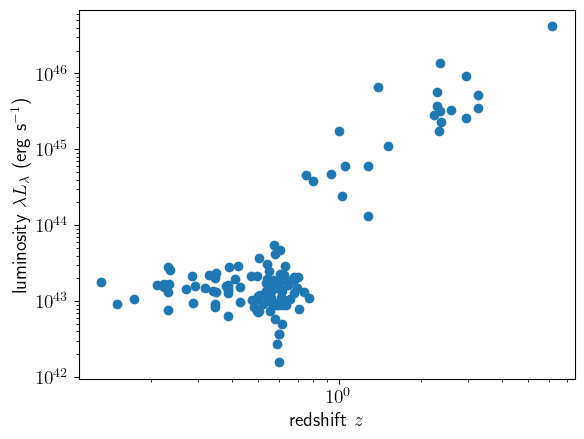

In [33]:
# add plotting command here
XX
plt.xlabel('redshift $z$'); plt.ylabel('luminosity $\lambda L_\lambda$ (erg s$^{-1}$)')

now do the same for the flux

Text(0, 0.5, 'flux $F_\\lambda$ (10$^{-17}$ erg cm$^{-2}$ s$^{-1}$ $\\AA^{-1}$')

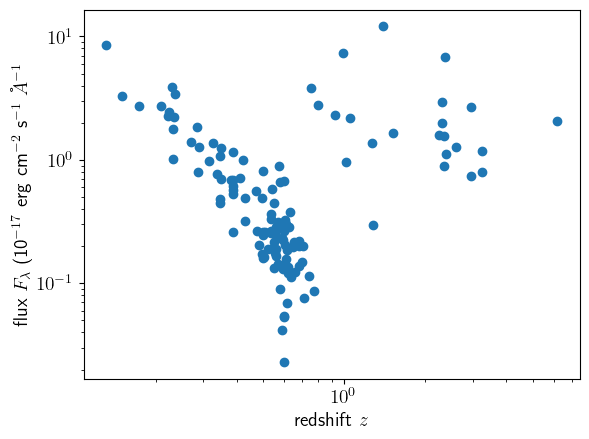

In [35]:
XX
plt.xlabel('redshift $z$'); plt.ylabel('flux $F_\lambda$ (10$^{-17}$ erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$')
plt.ylim(3e-1,1e2)

12. what do you make of the plot?

#### how do you reconcile these two results? which if either do you think is more representative of the intrinsic properties of quasars in the Universe? explain your reasoning.